# Superstore Sales Analysis - Business Insights

**Business question:** Which product categories, regions, and time periods drive the most sales and profit, and where should the business focus to improve?

**Dataset:** Sample Superstore (9,994 orders, 2014-2017)

**Tools:** Python, Pandas, Matplotlib, Seaborn

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/kaggle/input/datasets/vivek468/superstore-dataset-final/Sample - Superstore.csv', encoding='latin1')
print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [12]:
print(df.shape)        # how many rows and columns
print(df.columns)      # column names
print(df.isnull().sum()) # any missing values?

(9994, 21)
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


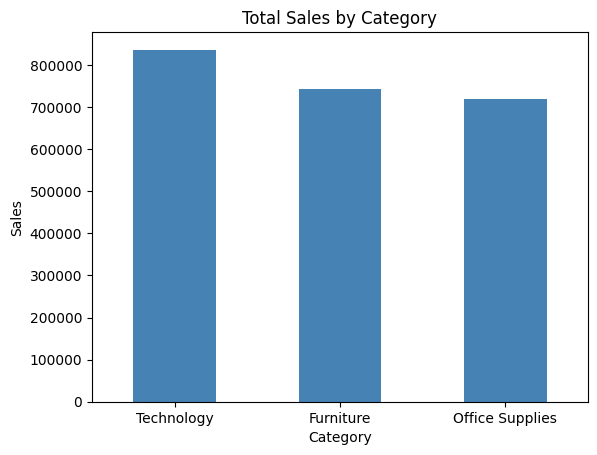

In [13]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(category_sales)

category_sales.plot(kind='bar', color='steelblue')
plt.title('Total Sales by Category')
plt.ylabel('Sales')
plt.xticks(rotation=0)
plt.show()

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


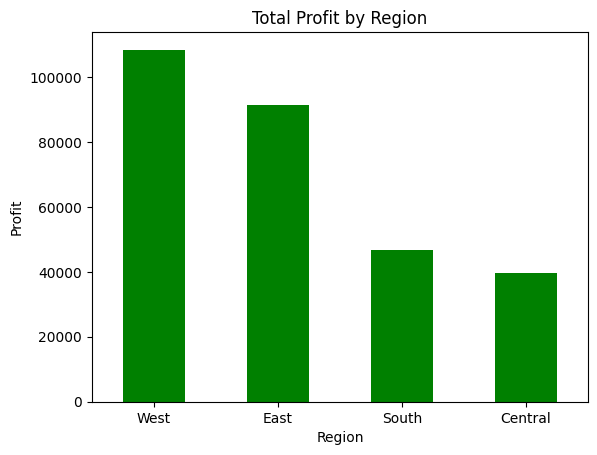

In [14]:
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
print(region_profit)

region_profit.plot(kind='bar', color='green')
plt.title('Total Profit by Region')
plt.ylabel('Profit')
plt.xticks(rotation=0)
plt.show()

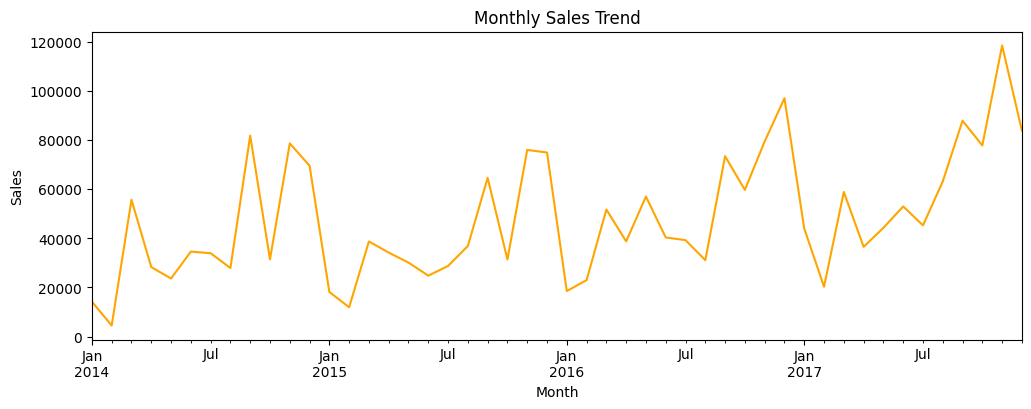

In [15]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month'] = df['Order Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Sales'].sum()
monthly_sales.plot(figsize=(12,4), color='orange')
plt.title('Monthly Sales Trend')
plt.ylabel('Sales')
plt.show()

## Key Business Insights

1. Technology is the highest revenue category
2. The West region generates the most profit
3. Sales peak during November-December (holiday season)
4. The Central region has the lowest profit — needs attention